# Model Inference & Explainability

## Objective

The objective of this notebook is to demonstrate how the trained machine learning model can be used to generate predictions for new employees, explain prediction decisions, and prepare the model for deployment within the Employee Attrition Platform.

### 1. Environment Setup & Pipeline Artifact Loading

**What this cell does:**
- Resolves project directory paths (`models/`, `data/processed/`, `reports/`).
- Loads trained model and preprocessing pipeline artifacts:
  - `best_model.joblib`: The saved Logistic Regression model selected during model evaluation.
  - `preprocessor.joblib`: The fitted `ColumnTransformer` handling feature scaling and encoding.
  - `feature_names.json`: The ordered list of transformed feature names.
  - `model_metadata.json`: Pipeline metadata containing the optimal classification threshold.
- Loads processed test (`X_test.pkl`, `y_test.pkl`) and training (`X_train.pkl`) datasets, then applies the fitted `preprocessor` to create transformed DataFrames (`X_test_df` and `X_train_df`).

**Why this step exists:**
- **Inference Readiness:** Prepares the environment by loading serialized artifacts to simulate an offline-to-online deployment flow.
- **Threshold Integrity:** The classification threshold (`optimal_threshold`) stored in metadata was selected in the model training notebook using cross-validated out-of-fold predictions strictly on training data—ensuring zero data leakage from the test set.
- **Baseline Requirement for SHAP:** Loading and transforming the training set `X_train` is necessary because linear SHAP explainers require a reference background distribution to establish baseline expectations when calculating feature contributions.

In [5]:
import json
import joblib
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# 1. Setup Directories
base_dir = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
artifacts_dir = base_dir / "artifacts"
processed_dir = base_dir / "data" / "processed"
reports_dir = base_dir / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

# 2. Load Serialized Pipeline & Model Artifacts
model = joblib.load(artifacts_dir / "model.joblib")
preprocessor = joblib.load(artifacts_dir / "preprocessor.joblib")

with open(artifacts_dir / "feature_names.json", "r") as f:
    feature_names = json.load(f)

with open(artifacts_dir / "metadata.json", "r") as f:
    metadata = json.load(f)

# 3. Load Test Data for SHAP Evaluation
X_test = pd.read_pickle(processed_dir / "X_test.pkl")
y_test = pd.read_pickle(processed_dir / "y_test.pkl")["Attrition"]

# 3b. Load Training Data — Logistic Regression's explainer needs a background
#     distribution (a "masker") to compute SHAP values against, unlike TreeExplainer
#     which could read the tree structure directly.
X_train = pd.read_pickle(processed_dir / "X_train.pkl")

# Preprocess Test & Train Features
X_test_transformed = preprocessor.transform(X_test)
X_train_transformed = preprocessor.transform(X_train)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

print(" All artifacts successfully loaded!")
print(f" Loaded Model: {metadata.get('model_name', 'LogisticRegression')}")
print(f" Optimal Classification Threshold: {metadata.get('optimal_threshold', 0.5):.3f}")

 All artifacts successfully loaded!
 Loaded Model: LogisticRegression
 Optimal Classification Threshold: 0.388


### 2. Core Prediction & Risk Tiering API Function

**What this cell does:**
- Defines `predict_employee_attrition()`, a function that:
  1. Accepts a raw employee feature dictionary (simulating an incoming JSON payload).
  2. Drops non-predictive/constant identifier fields (e.g., `EmployeeNumber`, `StandardHours`).
  3. Preprocesses the feature record using the loaded `ColumnTransformer`.
  4. Calculates the predicted attrition probability and evaluates it against the pre-set cross-validated threshold to determine `predicted_attrition` (boolean).
  5. Categorizes attrition risk into a 4-tier scale: **Low Risk** (<25%), **Medium Risk** (25% to threshold), **High Risk** (threshold to 65%), and **Critical Risk** (>= 65%).
- Tests the function using a sample employee record from `X_test` and prints the resulting JSON dictionary.

**Why this step exists:**
- **FastAPI Endpoint Prototyping:** Serves as the blueprint for the primary prediction endpoint in the production FastAPI backend.
- **Actionable Risk Categorization:** Translates continuous probabilities into discrete risk tiers to allow HR business partners to prioritize intervention strategies effectively.

In [6]:
def predict_employee_attrition(raw_employee_dict, preprocessor, model, metadata):
    """
    Simulates the core prediction pipeline for a single incoming API request.
    Converts raw feature dict into preprocessed array, calculates risk probability,
    and returns categorized risk tier.
    """
    # 1. Convert input payload to 1-row DataFrame
    sample_df = pd.DataFrame([raw_employee_dict])
    
    # 2. Drop constant/non-predictive columns if passed
    unwanted_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber', 'Attrition']
    sample_df = sample_df.drop(columns=unwanted_cols, errors='ignore')
    
    # 3. Transform features using serialized ColumnTransformer
    X_transformed = preprocessor.transform(sample_df)
    
    # 4. Predict probability & apply optimal threshold
    prob = float(model.predict_proba(X_transformed)[0, 1])
    optimal_thresh = metadata.get("optimal_threshold", 0.5)
    is_attrition = bool(prob >= optimal_thresh)
    
    # 5. Categorize risk tier for HR dashboard
    if prob < 0.25:
        risk_level = "Low Risk"
    elif prob < optimal_thresh:
        risk_level = "Medium Risk"
    elif prob < 0.65:
        risk_level = "High Risk"
    else:
        risk_level = "Critical Risk"
        
    return {
        "attrition_probability": round(prob, 4),
        "predicted_attrition": is_attrition,
        "optimal_threshold_used": round(optimal_thresh, 4),
        "risk_level": risk_level
    }

# Test with a single employee record from the test set
sample_employee = X_test.iloc[0].to_dict()
sample_prediction = predict_employee_attrition(sample_employee, preprocessor, model, metadata)

print("=== SAMPLE API PREDICTION OUTPUT ===")
print(json.dumps(sample_prediction, indent=4))

=== SAMPLE API PREDICTION OUTPUT ===
{
    "attrition_probability": 0.0701,
    "predicted_attrition": false,
    "optimal_threshold_used": 0.3877,
    "risk_level": "Low Risk"
}


### 3. Global SHAP Explainability & Explainer Initialization

**What this cell does:**
- Samples a background reference dataset of 200 rows from the transformed training set (`X_train_df`).
- Instantiates a global `shap.Explainer` with the Logistic Regression model and background reference sample.
- Computes SHAP values across all test set instances (`X_test_df`).
- Generates and exports two global explainability plots:
  1. **Beeswarm Plot:** Visualizes the magnitude, direction, and feature value impact on attrition risk across all test instances.
  2. **Bar Plot:** Ranks the top 12 most influential features by global mean absolute SHAP value.

**Why this step exists:**
- **`shap.Explainer` Model Auto-Detection:** `shap.Explainer` is used instead of `shap.TreeExplainer` because the final selected model is Logistic Regression (a linear model). `TreeExplainer` only supports tree-based models (e.g., CatBoost, XGBoost, Random Forest). `shap.Explainer` automatically detects the linear architecture and applies an appropriate linear explainer algorithm, providing exact (not approximated) feature attributions calculated directly from model coefficients multiplied by feature values.
- **Background Reference Sample:** Linear explainers require a baseline background distribution against which feature deviations are measured. Passing a representative sample of 200 training instances creates this reference baseline (unlike tree explainers, which can extract baseline values directly from tree structure nodes).
- **Explainer Build & Reuse Pattern:** Constructing the `explainer` object in this global setup step establishes a single reusable instance. Reconstructing an explainer on every prediction call is computationally wasteful and introduces significant latency. In production (FastAPI), the explainer is instantiated once during application startup and kept in memory to serve individual requests efficiently.

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


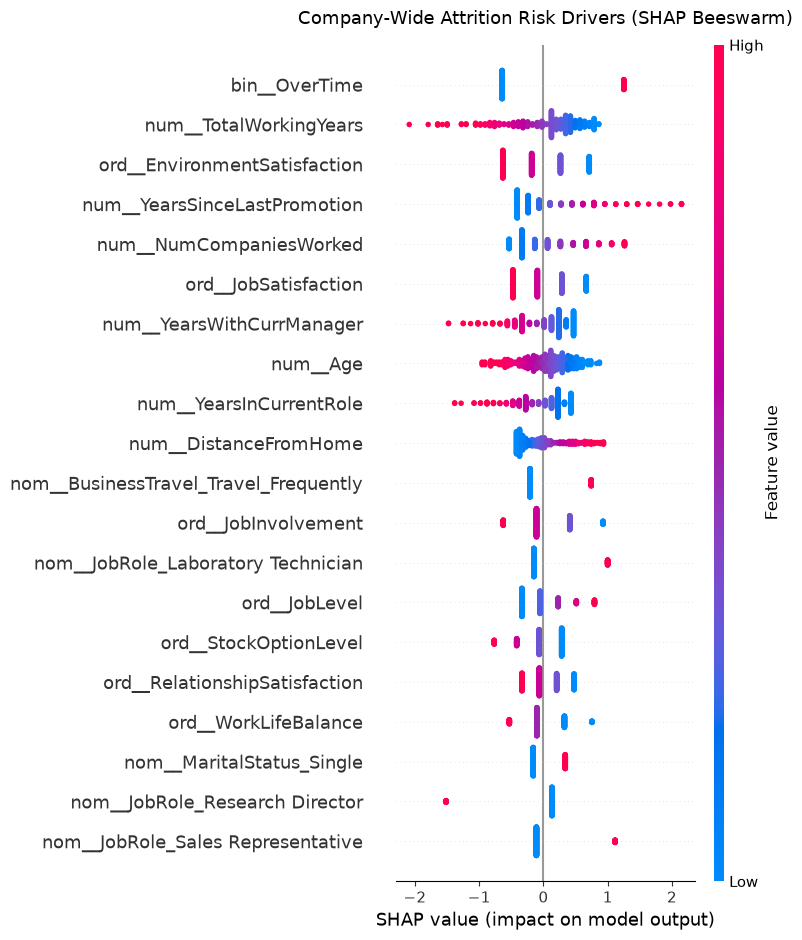

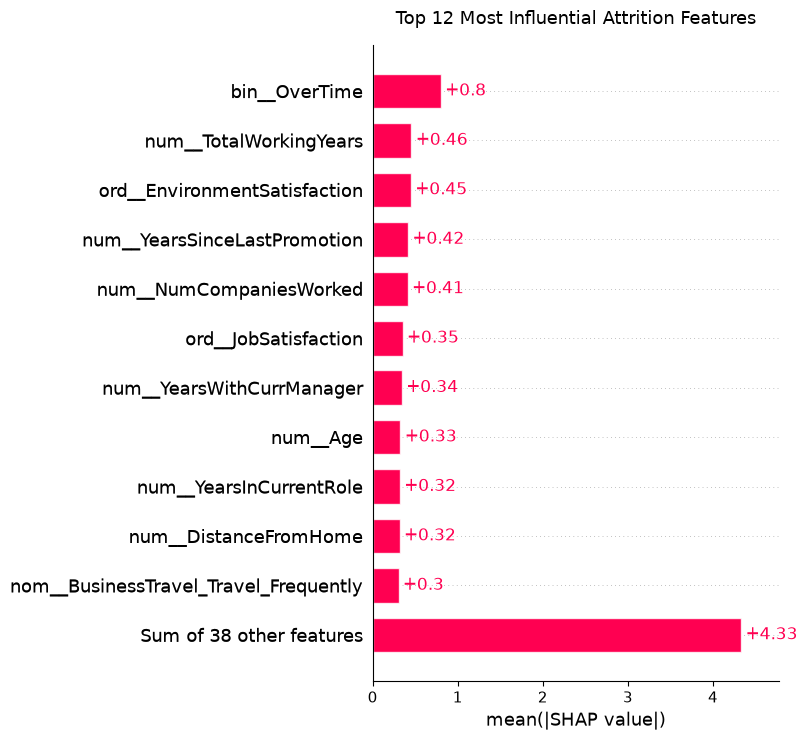

In [7]:
# 1. Instantiate SHAP Explainer — shap.Explainer auto-detects the model type
#    (LinearExplainer under the hood for LogisticRegression) rather than assuming trees.
#    A sample of the training set is used as the background reference distribution.
background = shap.sample(X_train_df, 200, random_state=42)
explainer = shap.Explainer(model, background)
shap_values = explainer(X_test_df)

# 2. Summary Beeswarm Plot (Shows magnitude and direction of feature impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("Company-Wide Attrition Risk Drivers (SHAP Beeswarm)", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(reports_dir / "shap_summary_beeswarm.png", dpi=300)
plt.show()

# 3. Global Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=12, show=False)
plt.title("Top 12 Most Influential Attrition Features", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(reports_dir / "shap_global_bar.png", dpi=300)
plt.show()

### 4. Local Explainability: Individual High-Risk Employee Waterfall Analysis

**What this cell does:**
- Identifies a high-risk employee instance from the test set where the predicted probability meets or exceeds the optimal threshold.
- Generates and saves an individual SHAP **Waterfall Plot** (`shap.plots.waterfall`) for that specific employee (`target_idx`).

**Why this step exists:**
- **Root-Cause Diagnostics:** While global plots show general model behavior across the company, local waterfall plots explain *why* a specific individual is flagged as high risk.
- **Visual Attribution Breakdown:** Shows how each feature value pushes the individual's risk score above or below the baseline expected log-odds, enabling HR specialists to design targeted retention actions for specific high-risk employees.

Analyzing Employee at Test Index #12
Predicted Attrition Risk: 40.08%


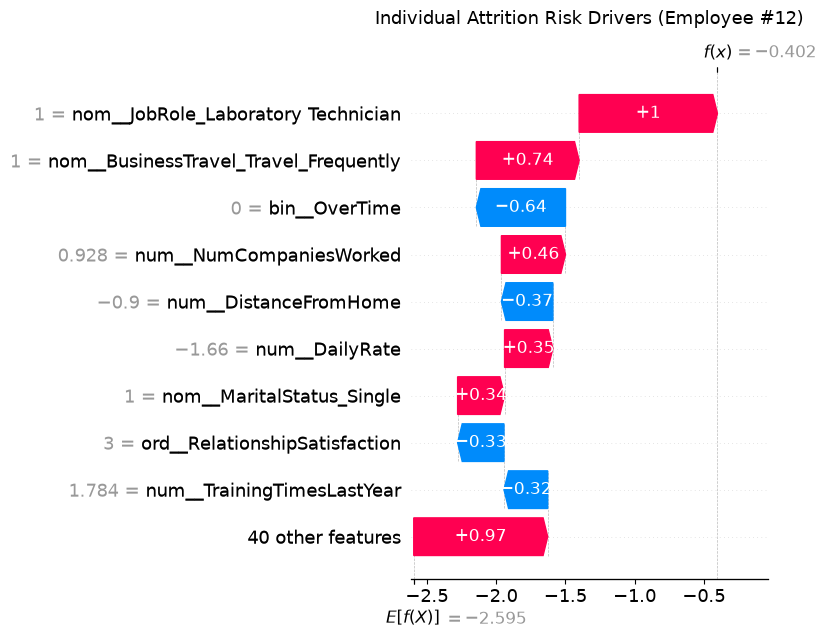

In [8]:
# Select a high-risk employee from test predictions
y_probs = model.predict_proba(X_test_transformed)[:, 1]
high_risk_indices = np.where(y_probs >= metadata.get("optimal_threshold", 0.5))[0]
target_idx = high_risk_indices[0] if len(high_risk_indices) > 0 else 0

print(f"Analyzing Employee at Test Index #{target_idx}")
print(f"Predicted Attrition Risk: {y_probs[target_idx]:.2%}")

# Plot Individual Waterfall Diagram
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[target_idx], max_display=10, show=False)
plt.title(f"Individual Attrition Risk Drivers (Employee #{target_idx})", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(reports_dir / f"employee_{target_idx}_shap_waterfall.png", dpi=300)
plt.show()

### 5. Structured Local SHAP Explanation API Function

**What this cell does:**
- Defines `get_employee_shap_explanation()`, a function that:
  1. Preprocesses a single raw employee feature dictionary.
  2. Computes SHAP values using the **cached, pre-built `explainer`** passed as an argument.
  3. Extracts the baseline log-odds value.
  4. Identifies the top $N$ feature drivers (default: 6), labeling each feature's directional impact as either `"Increases Risk"` or `"Decreases Risk"`.
  5. Formats output into a clean JSON-serializable structure containing `base_log_odds` and `top_feature_drivers`.
- Executes the function on a sample employee record and prints the formatted output.

**Why this step exists:**
- **Explainer Reuse in Production:** Passing the existing `explainer` object into the function enforces the architectural requirement that the explainer is instantiated once at startup and reused per request. Rebuilding the explainer inside function calls would add background sample processing overhead to every API hit, bottlenecking throughput.
- **Frontend Integration Ready:** Translates raw SHAP numerical outputs into human-readable labels (`Increases Risk` / `Decreases Risk`) formatted specifically for rendering explanatory widgets on the HR dashboard UI.

In [9]:
def get_employee_shap_explanation(sample_dict, preprocessor, explainer, feature_names, top_n=6):
    """
    Extracts top positive and negative SHAP feature contributions for a single employee,
    formatting them into a structured payload for frontend consumption.

    Takes the already-built `explainer` as a parameter instead of constructing a new one —
    building a LinearExplainer/TreeExplainer from scratch is expensive (background data
    processing) and should happen once at API startup, not on every request.
    """
    # 1. Preprocess input sample
    sample_df = pd.DataFrame([sample_dict]).drop(
        columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber', 'Attrition'],
        errors='ignore'
    )
    X_trans = preprocessor.transform(sample_df)
    X_trans_df = pd.DataFrame(X_trans, columns=feature_names)

    # 2. Compute SHAP values for single sample using the cached explainer
    single_shap = explainer(X_trans_df)[0]

    # 3. Extract baseline log-odds and feature SHAP values
    shap_array = single_shap.values
    base_value = float(single_shap.base_values)

    # 4. Construct feature contribution list
    contributions = []
    for feat_name, shap_val, feat_val in zip(feature_names, shap_array, X_trans_df.iloc[0]):
        contributions.append({
            "feature": feat_name,
            "shap_value": float(round(shap_val, 4)),
            "feature_value": float(round(feat_val, 4)),
            "impact": "Increases Risk" if shap_val > 0 else "Decreases Risk"
        })

    # 5. Sort by highest absolute SHAP magnitude
    sorted_drivers = sorted(contributions, key=lambda x: abs(x["shap_value"]), reverse=True)[:top_n]

    return {
        "base_log_odds": round(base_value, 4),
        "top_feature_drivers": sorted_drivers
    }

# Generate sample JSON response payload — pass the cached `explainer` from cell 3
explanation_payload = get_employee_shap_explanation(
    sample_employee,
    preprocessor,
    explainer,
    feature_names,
    top_n=5
)

print("=== SAMPLE FASTAPI SHAP EXPLANATION RESPONSE ===")
print(json.dumps(explanation_payload, indent=4))

=== SAMPLE FASTAPI SHAP EXPLANATION RESPONSE ===
{
    "base_log_odds": -2.5949,
    "top_feature_drivers": [
        {
            "feature": "nom__JobRole_Sales Representative",
            "shap_value": 1.1142,
            "feature_value": 1.0,
            "impact": "Increases Risk"
        },
        {
            "feature": "nom__BusinessTravel_Non-Travel",
            "shap_value": -0.9395,
            "feature_value": 1.0,
            "impact": "Decreases Risk"
        },
        {
            "feature": "num__TotalWorkingYears",
            "shap_value": 0.7876,
            "feature_value": -1.3291,
            "impact": "Increases Risk"
        },
        {
            "feature": "bin__OverTime",
            "shap_value": -0.6439,
            "feature_value": 0.0,
            "impact": "Decreases Risk"
        },
        {
            "feature": "ord__EnvironmentSatisfaction",
            "shap_value": -0.6315,
            "feature_value": 3.0,
            "impact": "Decreases

### 6. Full API Inference Pipeline Simulation

**What this cell does:**
- Defines `full_api_inference_pipeline()`, which orchestrates both `predict_employee_attrition()` and `get_employee_shap_explanation()` into a single composite function.
- Executes an end-to-end test on a sample employee payload and prints the complete JSON API response containing both prediction risk metrics and top local SHAP feature attributions.

**Why this step exists:**
- **End-to-End FastAPI Verification:** Simulates the exact contract of the primary production backend API endpoint. It proves that prediction scoring, risk tiering, and SHAP explainability attributions can be computed seamlessly in a single unified request lifecycle to power the frontend interface.

In [10]:
# Combined Inference + SHAP payload simulation (Complete FastAPI response)
def full_api_inference_pipeline(employee_raw_dict):
    pred = predict_employee_attrition(employee_raw_dict, preprocessor, model, metadata)
    explain = get_employee_shap_explanation(employee_raw_dict, preprocessor, explainer, feature_names)

    return {
        "prediction": pred,
        "explanation": explain
    }

final_api_response = full_api_inference_pipeline(sample_employee)
print(" Pipeline Verification Successful! Full API payload generated cleanly:")
print(json.dumps(final_api_response, indent=2))

 Pipeline Verification Successful! Full API payload generated cleanly:
{
  "prediction": {
    "attrition_probability": 0.0701,
    "predicted_attrition": false,
    "optimal_threshold_used": 0.3877,
    "risk_level": "Low Risk"
  },
  "explanation": {
    "base_log_odds": -2.5949,
    "top_feature_drivers": [
      {
        "feature": "nom__JobRole_Sales Representative",
        "shap_value": 1.1142,
        "feature_value": 1.0,
        "impact": "Increases Risk"
      },
      {
        "feature": "nom__BusinessTravel_Non-Travel",
        "shap_value": -0.9395,
        "feature_value": 1.0,
        "impact": "Decreases Risk"
      },
      {
        "feature": "num__TotalWorkingYears",
        "shap_value": 0.7876,
        "feature_value": -1.3291,
        "impact": "Increases Risk"
      },
      {
        "feature": "bin__OverTime",
        "shap_value": -0.6439,
        "feature_value": 0.0,
        "impact": "Decreases Risk"
      },
      {
        "feature": "ord__Environment